Neural Networks: MLP from scratch, image/text classification, learning-rate study, imbalanced-data metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_digits, make_classification, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              precision_recall_fscore_support, roc_curve, auc, accuracy_score)
from sklearn.feature_extraction.text import TfidfVectorizer

np.random.seed(42)
%matplotlib inline

## Q.1 — 2-Layer Neural Network (MLP) from scratch

Binary classifier with one hidden layer (tanh activation) and a sigmoid output layer, trained with
gradient descent on the Binary Cross-Entropy loss. Implemented using only `numpy`.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def initialize_parameters(n_x, n_h, n_y):
    rng = np.random.default_rng(1)
    W1 = rng.standard_normal((n_x, n_h)) * 0.1
    b1 = np.zeros((1, n_h))
    W2 = rng.standard_normal((n_h, n_y)) * 0.1
    b2 = np.zeros((1, n_y))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_propagation(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def compute_cost(A2, y):
    m = y.shape[0]
    eps = 1e-9
    A2 = np.clip(A2, eps, 1 - eps)
    cost = -np.sum(y * np.log(A2) + (1 - y) * np.log(1 - A2)) / m
    return float(cost)

def backward_propagation(X, y, params, cache):
    m = X.shape[0]
    W2 = params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    dZ2 = A2 - y                      # (m, 1)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1 - np.power(A1, 2))  # tanh derivative
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(params, grads, learning_rate):
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    return params

def train_mlp(X, y, hidden_nodes=4, learning_rate=0.1, epochs=1000):
    n_x = X.shape[1]
    n_y = 1
    y = y.reshape(-1, 1)
    params = initialize_parameters(n_x, hidden_nodes, n_y)
    costs = []
    for i in range(epochs):
        A2, cache = forward_propagation(X, params)
        cost = compute_cost(A2, y)
        costs.append(cost)
        grads = backward_propagation(X, y, params, cache)
        params = update_parameters(params, grads, learning_rate)
    return params, costs

def predict_mlp(X, params):
    A2, _ = forward_propagation(X, params)
    return (A2 > 0.5).astype(int)

In [3]:
# Data: make_moons, noise=0.20, 400 points
X, y = make_moons(n_samples=400, noise=0.20, random_state=42)

params, costs = train_mlp(X, y, hidden_nodes=4, learning_rate=0.1, epochs=1000)

y_pred = predict_mlp(X, params).ravel()
train_acc = accuracy_score(y, y_pred)
print(f"Final training accuracy: {train_acc:.3f}")
print(f"Final training cost: {costs[-1]:.4f}")

Final training accuracy: 0.843
Final training cost: 0.3128


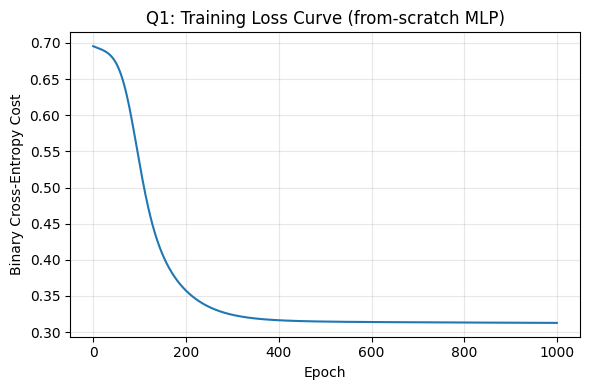

In [4]:
# Loss curve
plt.figure(figsize=(6, 4))
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Cost")
plt.title("Q1: Training Loss Curve (from-scratch MLP)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

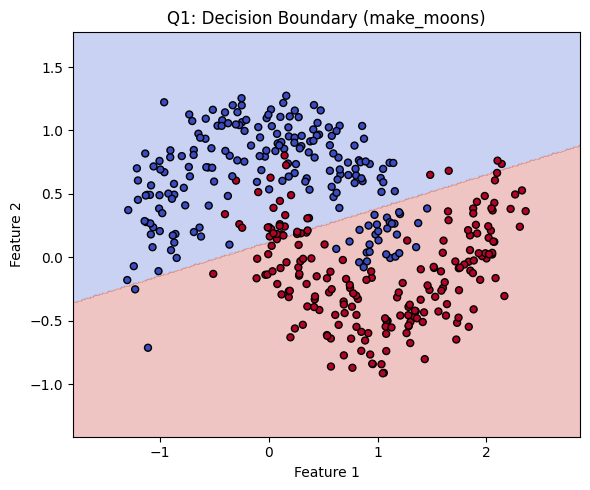

In [5]:
# Decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_mlp(grid, params).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Q1: Decision Boundary (make_moons)")
plt.tight_layout()
plt.show()

## Q.2 — Multi-class Image Classification (Digits dataset)

In [6]:
digits = load_digits()
Xd, yd = digits.data, digits.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.20, random_state=42, stratify=yd)

scaler = StandardScaler()
Xd_train_s = scaler.fit_transform(Xd_train)
Xd_test_s = scaler.transform(Xd_test)

clf_digits = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
clf_digits.fit(Xd_train_s, yd_train)

yd_pred = clf_digits.predict(Xd_test_s)
print(f"Test accuracy: {accuracy_score(yd_test, yd_pred):.3f}")

Test accuracy: 0.972


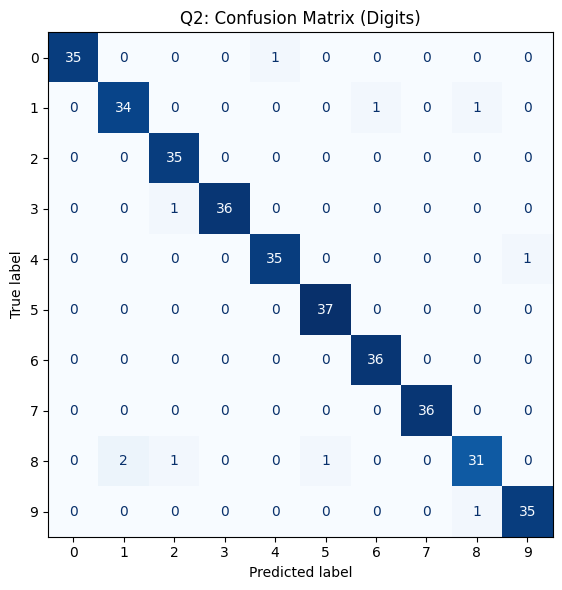

In [7]:
# Confusion matrix
cm = confusion_matrix(yd_test, yd_pred)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=digits.target_names).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Q2: Confusion Matrix (Digits)")
plt.tight_layout()
plt.show()

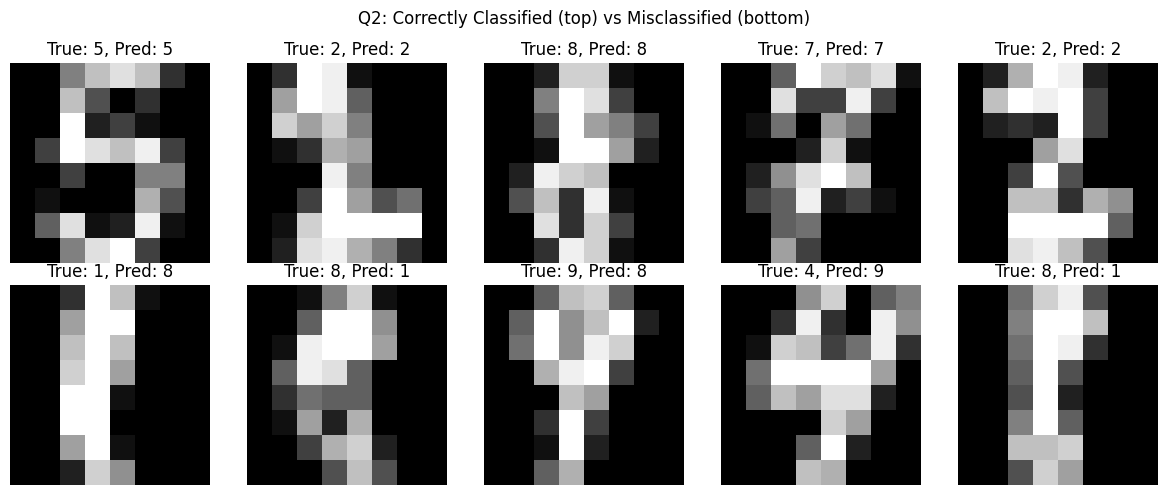

In [8]:
# 5 correctly classified and 5 misclassified test images
correct_idx = np.where(yd_pred == yd_test)[0][:5]
wrong_idx = np.where(yd_pred != yd_test)[0]

if len(wrong_idx) < 5:
    print(f"Only {len(wrong_idx)} misclassified samples found; showing all of them.")
wrong_idx = wrong_idx[:5]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col, idx in enumerate(correct_idx):
    img = Xd_test[idx].reshape(8, 8)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f"True: {yd_test[idx]}, Pred: {yd_pred[idx]}")
    axes[0, col].axis('off')

for col, idx in enumerate(wrong_idx):
    img = Xd_test[idx].reshape(8, 8)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f"True: {yd_test[idx]}, Pred: {yd_pred[idx]}")
    axes[1, col].axis('off')
for col in range(len(wrong_idx), 5):
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("Correct", fontsize=12)
fig.suptitle("Q2: Correctly Classified (top) vs Misclassified (bottom)")
plt.tight_layout()
plt.show()

## Q.3 — Effect of Learning Rate on Convergence

In [9]:
X3, y3 = make_moons(n_samples=500, noise=0.2, random_state=42)

learning_rates = [0.001, 0.01, 0.1, 1.0]
loss_curves = {}

for lr in learning_rates:
    clf = MLPClassifier(hidden_layer_sizes=(10,), solver='sgd',
                         learning_rate_init=lr, max_iter=500, random_state=42)
    clf.fit(X3, y3)
    loss_curves[lr] = clf.loss_curve_
    print(f"lr={lr}: final loss={clf.loss_curve_[-1]:.4f}, epochs run={len(clf.loss_curve_)}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


lr=0.001: final loss=0.2972, epochs run=500


lr=0.01: final loss=0.2099, epochs run=500
lr=0.1: final loss=0.2498, epochs run=114
lr=1.0: final loss=0.0400, epochs run=95


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


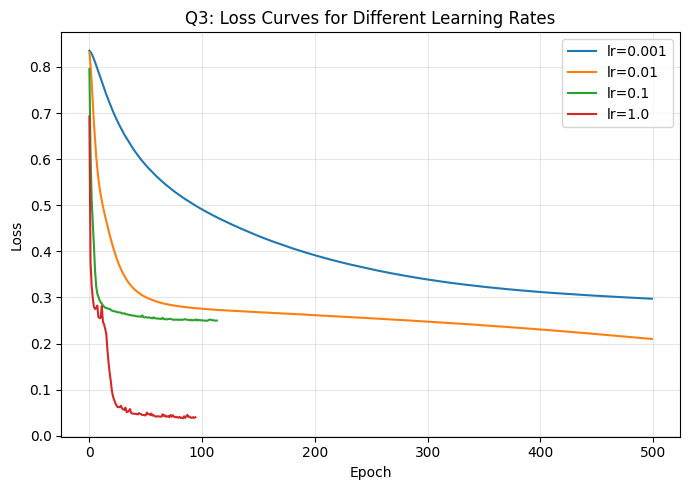

In [10]:
plt.figure(figsize=(7, 5))
for lr in learning_rates:
    plt.plot(loss_curves[lr], label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Q3: Loss Curves for Different Learning Rates")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis.** A very small learning rate (0.001) makes the loss decrease smoothly but very
slowly, so the network has not converged within 500 iterations. Moderate rates (0.01, 0.1) converge
much faster and reach a low, stable loss, with 0.1 typically converging fastest while remaining stable.
When the learning rate is set too high (1.0), the update steps overshoot the minimum of the loss
surface: the loss curve becomes noisy/oscillatory and may plateau at a higher value or fail to
decrease steadily, since the optimizer keeps jumping past good solutions instead of settling into
them. This illustrates the classic bias–variance-of-optimization trade-off: too low wastes
iterations, too high causes instability/divergence, and a well-tuned intermediate value gives the
best convergence speed and stability.

## Q.4 — Class Imbalance & Advanced Evaluation Metrics

In [11]:
X4, y4 = make_classification(n_samples=1000, weights=[0.90, 0.10],
                              n_informative=5, n_redundant=2, random_state=42)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.20, random_state=42, stratify=y4)

clf4 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
clf4.fit(X4_train, y4_train)

y4_pred = clf4.predict(X4_test)
y4_proba = clf4.predict_proba(X4_test)[:, 1]

overall_acc = accuracy_score(y4_test, y4_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y4_test, y4_pred, average='binary', pos_label=1)

print(f"Overall Accuracy: {overall_acc:.3f}")
print(f"Minority class (1) -> Precision: {precision:.3f}, Recall: {recall:.3f}, F1-score: {f1:.3f}")

Overall Accuracy: 0.955
Minority class (1) -> Precision: 0.875, Recall: 0.667, F1-score: 0.757


ROC-AUC: 0.941


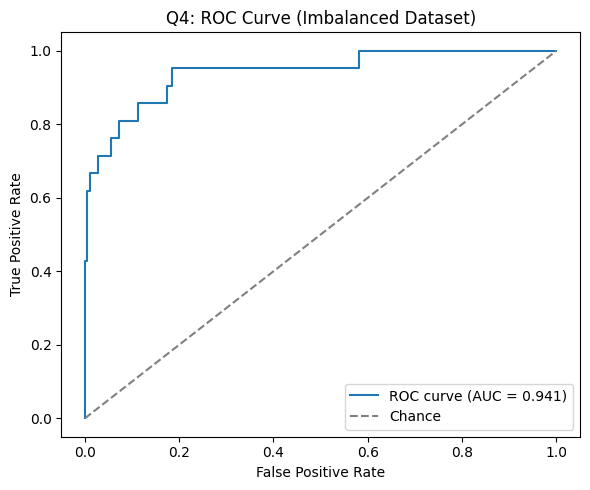

In [12]:
fpr, tpr, thresholds = roc_curve(y4_test, y4_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC: {roc_auc:.3f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Q4: ROC Curve (Imbalanced Dataset)")
plt.legend()
plt.tight_layout()
plt.show()

**Analysis.** With a 90/10 class split, a trivial classifier that always predicts the majority
class already achieves ~90% overall accuracy while being completely useless for detecting the
minority class. Accuracy therefore hides poor minority-class performance and is misleading here.
F1-score directly balances precision and recall *for the minority class*, so it penalizes a model
that ignores that class even if overall accuracy looks high. ROC-AUC evaluates the model's ability to
rank positive examples above negative ones across all classification thresholds, independent of the
class proportions, making it a more robust indicator of discriminative power on imbalanced data. Both
metrics therefore give a far more honest picture of performance on the minority class than raw
accuracy.

## Q.5 — Text Classification with Neural Networks (20 Newsgroups)

In [ ]:
categories = ["sci.med", "comp.graphics", "rec.sport.baseball"]
newsgroups = fetch_20newsgroups(subset='all', categories=categories,
                                 remove=('headers', 'footers', 'quotes'), random_state=42)

# Cap at 3000 documents as required
X_text = newsgroups.data[:3000]
y_text = newsgroups.target[:3000]
print(f"Number of documents used: {len(X_text)}")
print(f"Classes: {list(newsgroups.target_names)}")

In [ ]:
vectorizer = TfidfVectorizer(max_features=2000)
X_tfidf = vectorizer.fit_transform(X_text)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_tfidf, y_text, test_size=0.30, random_state=42, stratify=y_text)

clf_text = MLPClassifier(hidden_layer_sizes=(100,), early_stopping=True, random_state=42, max_iter=200)
clf_text.fit(Xt_train, yt_train)

yt_pred = clf_text.predict(Xt_test)
text_acc = accuracy_score(yt_test, yt_pred)

print(f"Overall Accuracy: {text_acc:.3f}\n")
print("Classification Report:")
print(classification_report(yt_test, yt_pred, target_names=newsgroups.target_names))

epochs_trained = len(clf_text.loss_curve_)
print(f"Number of epochs trained before early stopping: {epochs_trained}")

Because `early_stopping=True`, training stopped once the validation score failed to improve for
several consecutive iterations (rather than running the full `max_iter=200`), which is reported above
as the number of epochs actually completed (`len(model.loss_curve_)`).